### setup

In [2]:
## import dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [3]:
## configurations
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:'%.3f'%x) ## cancel scientific notation when tere are many decimal points
sns.set_theme(style='darkgrid')
RANDOM_STATE = 42

### Problem statement

- Dataset - Breast Cancer Wisconsin dataset
- building a model classify breast cancer stages

### Data collection

In [4]:
df = pd.read_csv("breast_cancer_dataset.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [5]:
df.shape

(569, 32)

### EDA

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
## missing values
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [9]:
## encoded missing values
for col in df.columns:
    print(col)
    print(df[col].value_counts().head(10))

id
id
842302      1
842517      1
84300903    1
84348301    1
84358402    1
843786      1
844359      1
84458202    1
844981      1
84501001    1
Name: count, dtype: int64
diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64
radius_mean
radius_mean
12.340    4
11.060    3
10.260    3
12.770    3
13.050    3
13.850    3
12.180    3
11.600    3
13.000    3
11.710    3
Name: count, dtype: int64
texture_mean
texture_mean
16.840    3
19.830    3
15.700    3
20.520    3
18.220    3
14.930    3
18.900    3
17.460    3
16.850    3
20.130    2
Name: count, dtype: int64
perimeter_mean
perimeter_mean
82.610     3
134.700    3
87.760     3
129.100    2
82.690     2
132.900    2
130.000    2
81.350     2
94.250     2
58.790     2
Name: count, dtype: int64
area_mean
area_mean
512.200     3
394.100     2
399.800     2
1076.000    2
582.700     2
334.200     2
1075.000    2
561.000     2
716.600     2
466.100     2
Name: count, dtype: int64
smoothness_mean
smoothness_mean
0.101    5
0.105  

In [10]:
## identified fuplicated
duplicate_mask = df.duplicated()
num_duplicated = duplicate_mask.sum()
num_duplicated

## df.drop_duplicates()
## this drops duplicate values


np.int64(0)

In [11]:
## class distribution
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B   62.742
M   37.258
Name: proportion, dtype: float64


In [12]:
## map target 
df["diagnosis"]=df["diagnosis"].map({"B":0,"M":1})

In [13]:
print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64


In [14]:
df.drop("id",axis=1).groupby("diagnosis").mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063,0.284,1.220,2.000,21.135,0.007,0.021,0.026,0.010,0.021,0.004,13.380,23.515,87.006,558.899,0.125,0.183,0.166,0.074,0.270,0.079
1,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063,0.609,1.211,4.324,72.672,0.007,0.032,0.042,0.015,0.020,0.004,21.135,29.318,141.370,1422.286,0.145,0.375,0.451,0.182,0.323,0.092


In [15]:
## return number of unique values
num_of_rows = len(df)
num_of_unique = df.nunique()

constant_columns = num_of_unique[num_of_unique==1].index.to_list()
print(constant_columns)
# number

[]


In [16]:
quasi_constant_cols = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True,dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_columns:
        quasi_constant_cols.append(col)


print(f"quasi constant columns(more thean 95% of values containing one value):\n {quasi_constant_cols}")

quasi constant columns(more thean 95% of values containing one value):
 []


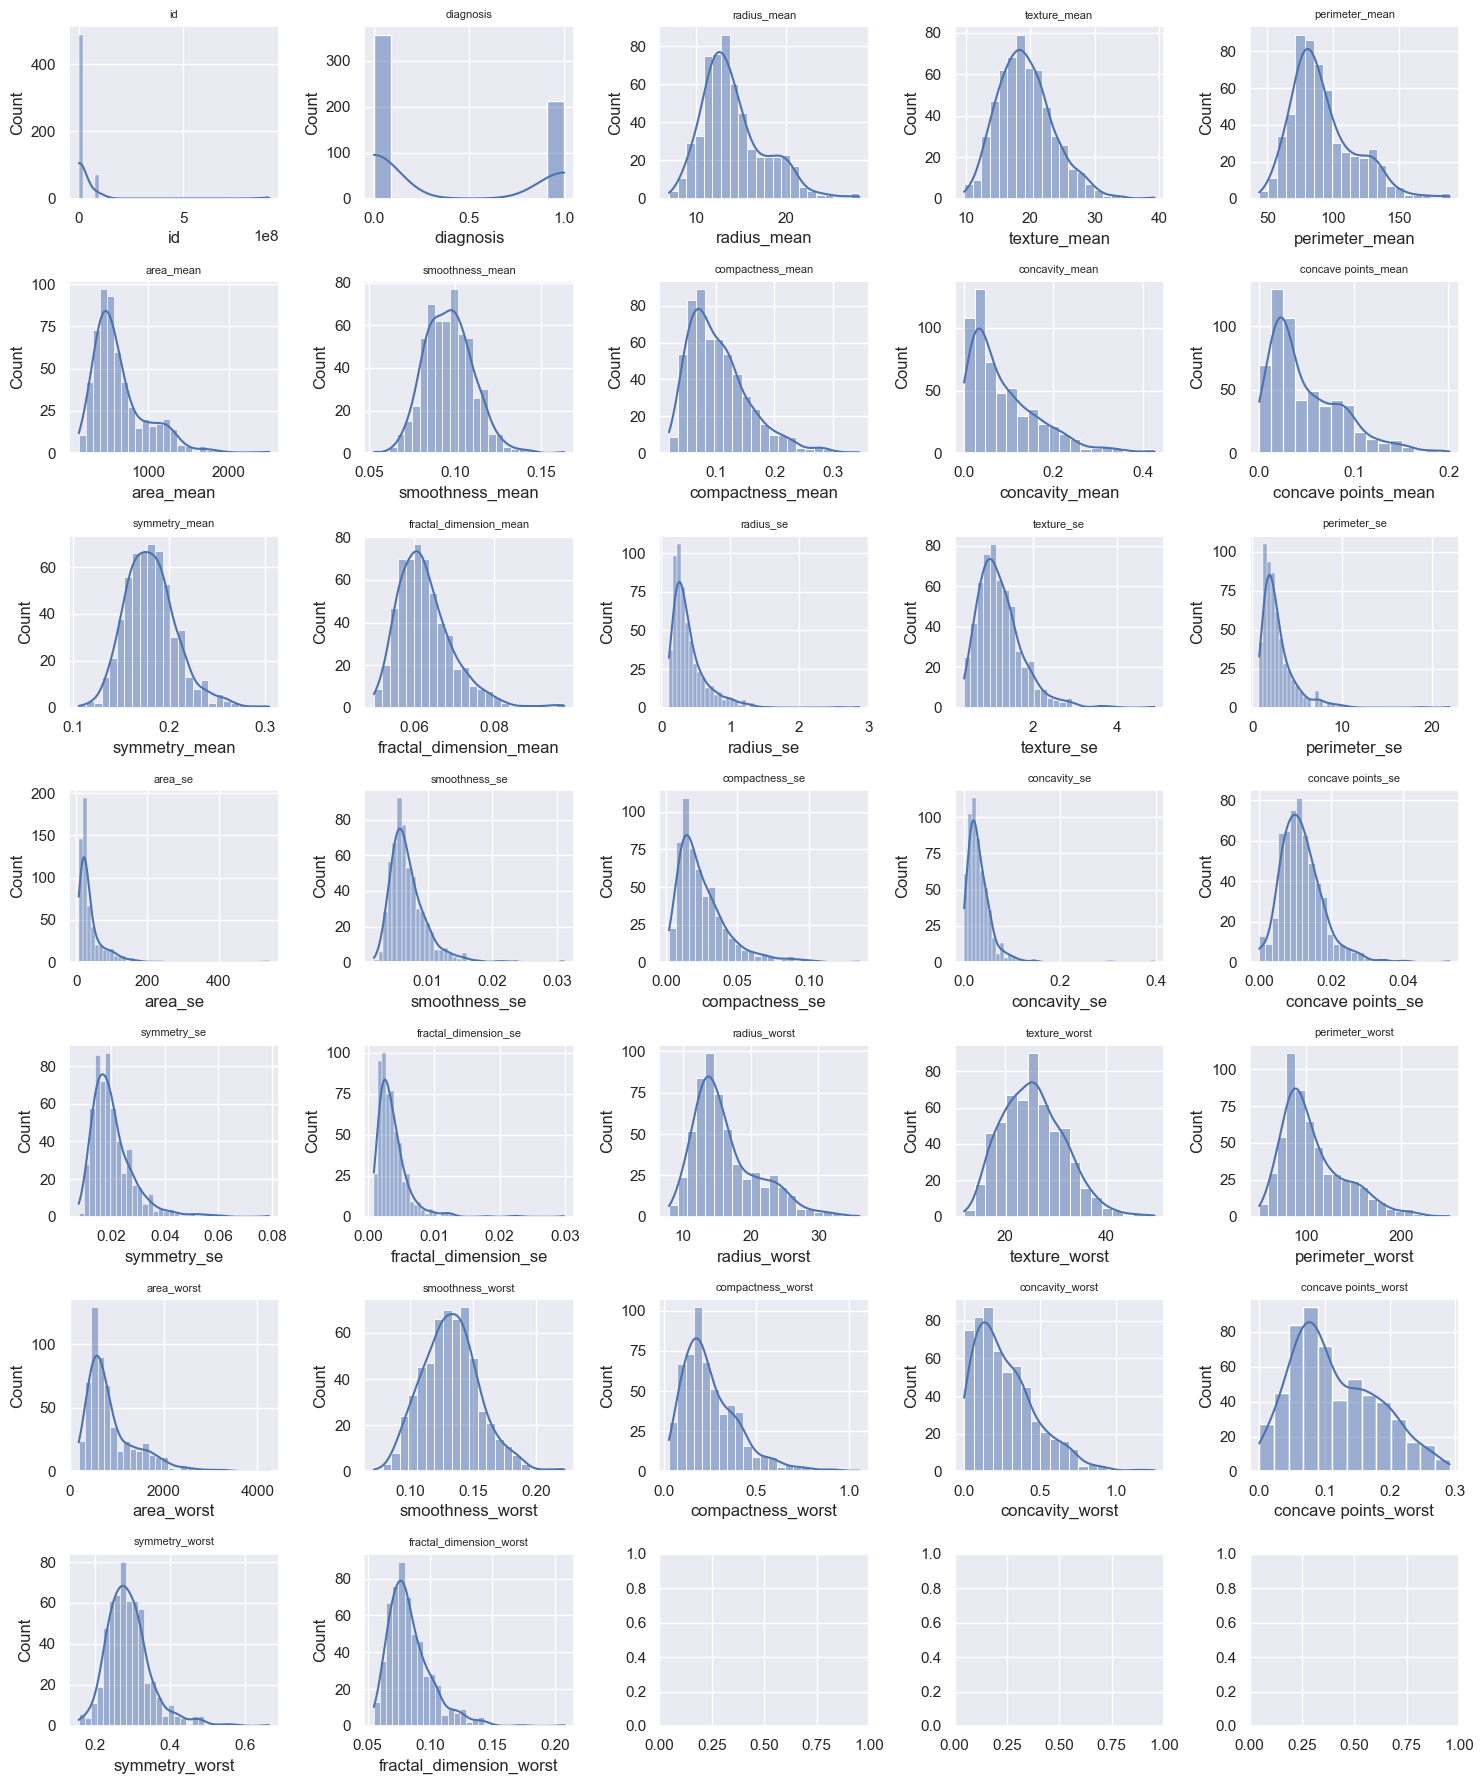

In [17]:
## histogram for distribution analysis
fig,axes = plt.subplots(7,5, figsize=(15,18))
axes = axes.flatten()

for i,col in enumerate(df.columns):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()

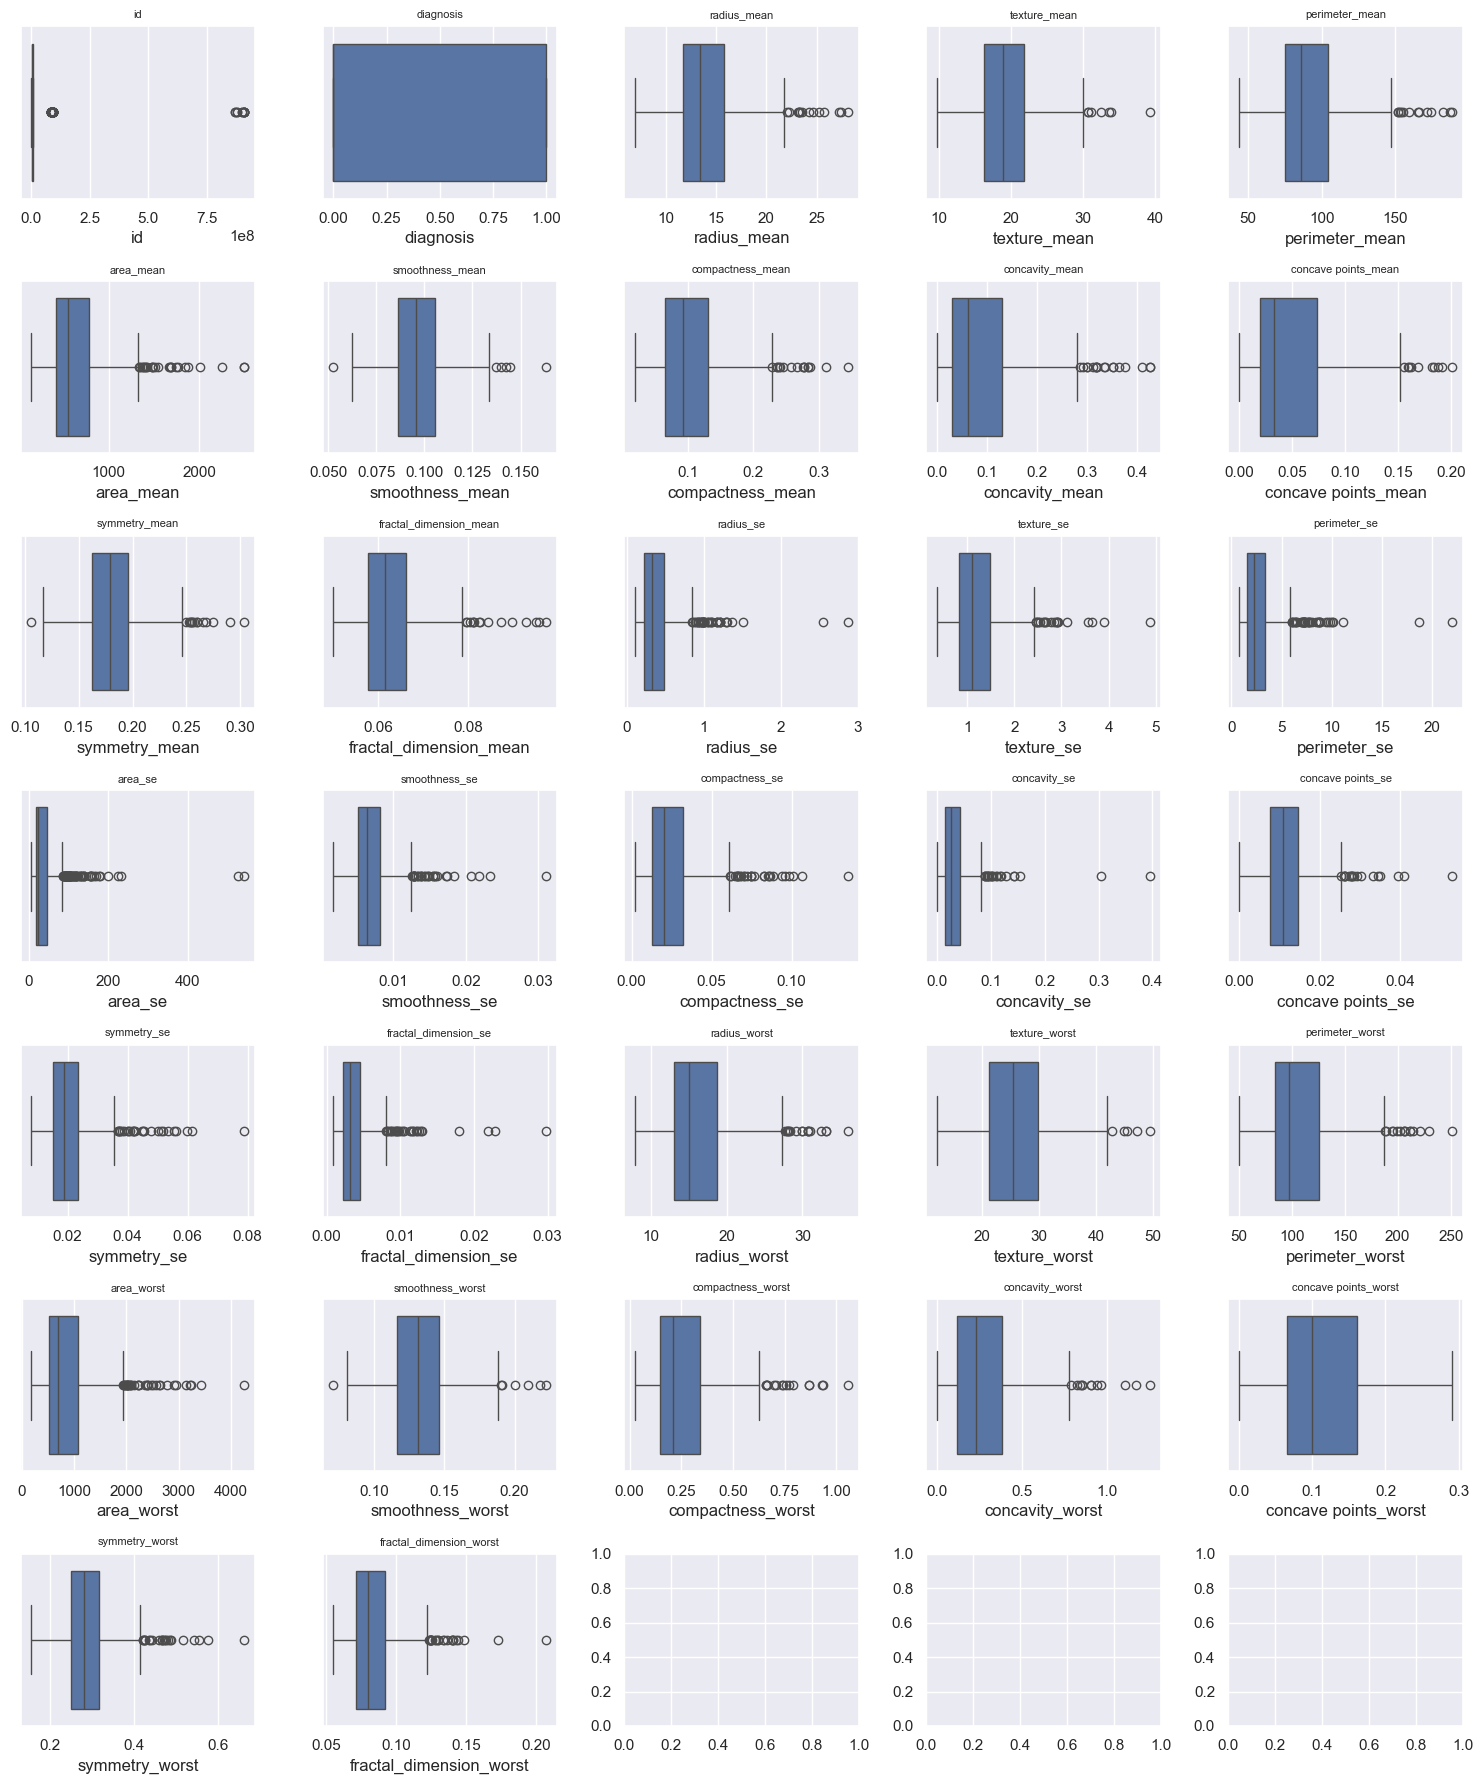

In [18]:
## outlier analysis - box plot
fig,axes = plt.subplots(7,5, figsize=(15,18))
axes = axes.flatten()

for i,col in enumerate(df.columns):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()

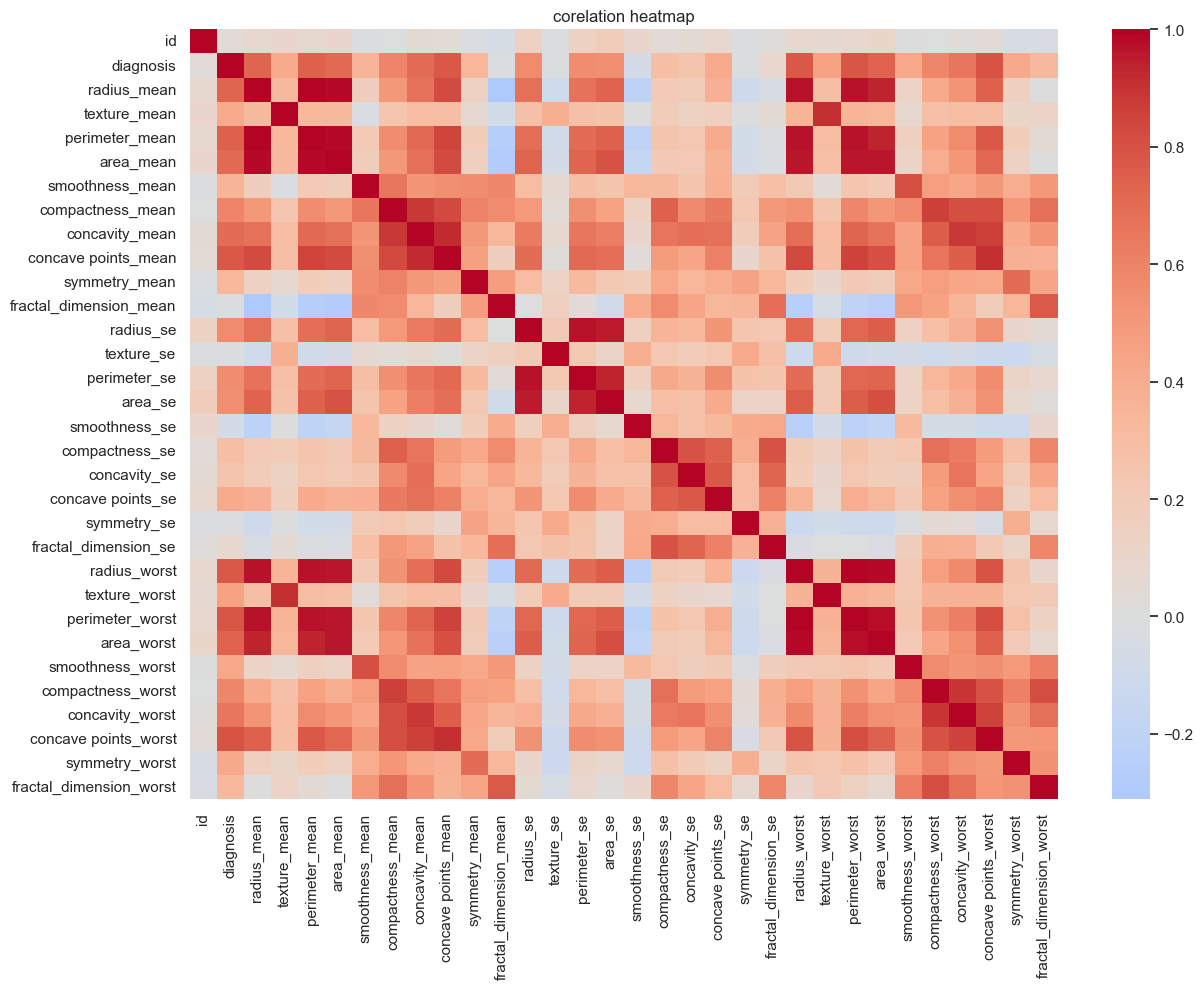

In [19]:
## identify the presence of highly correlated columns and feature relationships
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),cmap='coolwarm',center=0)
plt.title("corelation heatmap")
plt.show()

### insights
- drop id column
- all features are numerical
- high dimentional feature space
- no missing values
- slight class imbalance, adress after baseline using precision and recall
- recall is primary priority metric since false negatives are critical
- strong separation in feature means between classes, model wii able to classify clearly
- extreme values often represent malignant classes, not noice
- Highly correlated features are present, we can perform feature selection/ PCA

### Data preprocessing

In [20]:
## separate data into features and target
X = df.drop(columns=['id','diagnosis'])
y = df['diagnosis']

In [21]:
## train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE)

In [22]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(569, 30)
(455, 30)
(114, 30)


### model training

#### baseline model - Logistic regression

In [23]:
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model = LogisticRegression()

In [26]:
## training a model
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
## training accuray
model.score(X_train_scaled,y_train)

0.9868131868131869

In [28]:
## test accuray
model.score(X_test_scaled,y_test)

0.9649122807017544

### Optimization

In [29]:
pipeline = Pipeline(
    [
        ("scaler",StandardScaler()),
        ('pca',PCA()),
        ('model',SVC(kernel="rbf"))
    ]
)

In [30]:
## grid of hyperparameters
param_grid = [
    {
        "pca__n_components":[10,15,20,25,30],
        "model__C":[0.1,1,10,100,1000],
        "model__gamma":[0.001,0.01,0.1,1,"scale"]
     }
]

In [31]:
## cross validation setup
k =5
skf = StratifiedKFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [32]:
## hyper parameter tuning
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring='recall',
    cv=skf,
    n_jobs =-1
)

In [33]:
grid_search.fit(X_train,y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"[{'model__C': [0.1, 1, ...], 'model__gamma': [0.001, 0.01, ...], 'pca__n_components': [10, 15, ...]}]"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [34]:
print("best parameters",grid_search.best_params_)
print("best score",grid_search.best_score_)

best parameters {'model__C': 10, 'model__gamma': 'scale', 'pca__n_components': 10}
best score 0.9647058823529411


In [35]:
## train with best params
best_pipeline = Pipeline(
    [
        ("scaler",StandardScaler()),
        ('pca',PCA(n_components=10)),
        ('model',SVC(C=10,gamma='scale',kernel="rbf"))
    ]
)

In [36]:
best_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'


In [37]:
best_pipeline_pred = best_pipeline.predict(X_test)

### Evaluation 

In [38]:
y_pred = best_pipeline.predict(X_test)

In [39]:
accuracy_score(y_test,y_pred)

0.9649122807017544

Text(17.249999999999993, 0.5, 'Actual')

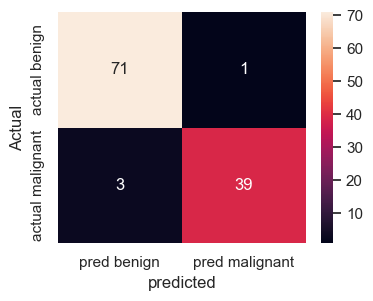

In [40]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True,xticklabels=["pred benign","pred malignant"],yticklabels=["actual benign","actual malignant"])
plt.xlabel("predicted")
plt.ylabel("Actual")

In [41]:
print(classification_report(y_test,y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.9595    0.9861    0.9726        72
           1     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



### Inference

In [ ]:
## build a predictive system
## for multiple predictions
def predict_cancer(data,model):
    predictions = model.predict(data)
    for row,prediction in zip(data.itertuples(index=False), predictions):
        if prediction == 1:
            print(row)
            print("Diagnosis --> malignant")
        elif prediction == 0:
            print(row)
            print("Diagnosis --> benign")


In [ ]:
## for single predictio
def predict_cancer(data,model):
    data = pd.DataFrame([data])
    predictions = model.predict(data)
    for prediction in  (predictions):
        if prediction == 1:
            print("Diagnosis --> malignant")
        elif prediction == 0:
            print("Diagnosis --> benign")


In [87]:
input = X_test.iloc()[0].to_list()
input

[11.41,
 10.82,
 73.34,
 403.3,
 0.09373,
 0.06685,
 0.03512,
 0.02623,
 0.1667,
 0.06113,
 0.1408,
 0.4607,
 1.103,
 10.5,
 0.00604,
 0.01529,
 0.01514,
 0.00646,
 0.01344,
 0.002206,
 12.82,
 15.97,
 83.74,
 510.5,
 0.1548,
 0.239,
 0.2102,
 0.08958,
 0.3016,
 0.08523]

In [91]:
predict_cancer(input,best_pipeline)

Diagnosis --> benign


c:\Users\chama\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [93]:
y_test.iloc[0]

np.int64(0)